In [1]:
##3.3.1 Configurer l’environnement et importer les packages Python
#Les bibliothèques Python nécessaires doivent être importées. Cela inclut les bibliothèques standard de cartographie et d’analyse géospatiale, ainsi que les fonctions utilitaires spécifiques à Digital Earth Africa pour l’accès aux données des masses d’eau et leur visualisation.
#_________________________________________________________

# Importer les bibliothèques et modules nécessaires

import matplotlib.pyplot as plt

 

# Étendre le chemin système pour inclure le répertoire des outils DE Africa (si nécessaire) 

import sys

sys.path.insert(1, '../Tools/')

 

# Fonctions utilitaires de Digital Earth Africa pour la cartographie et les masses d’eau

from deafrica_tools.plotting import display_map

from deafrica_tools.waterbodies import (

    get_geohashes,

    get_waterbodies,

    get_waterbody,

    get_time_series,

)

#_________________________________________________________

#Ce que vous allez faire: 

#Chargement des bibliothèques pour tracer des cartes (matplotlib), afficher des cartes interactives avec des boîtes de délimitation (display_map), et accéder aux masses d’eau de DEA (dea_tools pour lister les polygones et obtenir des séries temporelles). L’importation doit être effectuée avant tout appel aux fonctions liées aux masses d’eau de DE Africa.

In [2]:
## 3.3.2 Définir les paramètres d’analyse
#Nous allons analyser chaque barrage individuellement. Pour chaque barrage, définissez une boîte englobante (lon_min, lon_max, lat_max, lat_min) couvrant son réservoir. Vous pouvez modifier ces valeurs afin de cibler d’autres barrages.

  

#Voici les coordonnées approximatives des cinq barrages ciblés :

#Gariep Dam (Orange River):

#lon: 25.0 E – 25.8 E
#lat: 30.8 S – 30.5 S
# Vanderkloof Dam (Orange River):

#lon: 24.6 E – 24.9 E
#lat: 30.1 S – 29.9 S
# Theewaterskloof Dam (Western Cape):

#lon: 19.1 E – 19.3 E
#lat: 34.12 S – 33.98 S
# Vaal Dam (Vaal River):

#lon: 27.6 E – 28.3 E
#lat: 27.2 S – 26.7 S
#Midmar Dam (KwaZulu-Natal):

#lon: 30.12 E – 30.25 E
#lat: 29.57 S – 29.45 S
#Nous commençons ci-dessous avec le barrage de Theewaterskloof. Vous pouvez modifier xlim/ylim pour analyser d’autres barrages.

#_________________________________________________________

# Définir la zone d’intérêt (AOI) pour le barrage de Theewaterskloof 

# (xlim correspond à l’intervalle de longitude et ylim à l’intervalle de latitude) 

xlim = (19.1, 19.3)        # Lon min, Lon max

ylim = (-33.98, -34.12)    # Lat max (nord), Lat min (sud) – note: les latitudes sud sont négatives.

 

# Afficher une carte interactive pour vérifier que l'AOI couvre le barrage

display_map(xlim, ylim)

#_________________________________________________________

#Ce que vous allez faire:

#Définir la zone d’intérêt (AOI) autour du barrage de Theewaterskloof. La fonction display_map permet de vérifier visuellement que la boîte englobante couvre bien le réservoir. (Dans un document statique, vous pouvez ignorer cette carte après avoir confirmé les coordonnées.)
#Figure 3.3.1: Boîte englobante de la zone d’intérêt (AOI) autour du barrage de Theewaterskloof

In [3]:
### 3.3.3 Suivi des masses d’eau à l’aide des données historiques
#Le service Waterbodies de DE Africa fournit des polygones de « l’étendue historique » (zones où l’eau est apparue ≥ 5 % du temps dans les observations claires) ainsi que des séries temporelles des « variations de surface » pour chaque plan d’eau. Dans cette section, vous apprendrez à :

#Récupérer tous les plans d’eau présents dans notre zone d’intérêt (via get_geohashes).
#Charger leurs polygones (via get_waterbodies) et les visualiser.
#Extraire la série temporelle de la surface en eau d’un réservoir sélectionné (via get_time_series).
## 3.3.3a Obtenir les geohashes des plans d’eau
#Commencez par construire la boîte englobante dans l’ordre suivant : (min_lon, min_lat, max_lon, max_lat). Ensuite, utilisez la fonction get_geohashes pour lister tous les identifiants des plans d’eau présents dans cette région.
#_________________________________________________________

# Créer un tuple de boîte englobante à partir de nos coordonnées: (min_lon, min_lat, max_lon, max_lat) 

bbox = (xlim[0], ylim[1], xlim[1], ylim[0])

print("Boîte englobante:", bbox)

 

# Interroger le service Waterbodies pour obtenir les geohashes (ID des plans d’eau) dans cette région

geohash_list = get_geohashes(bbox, crs="EPSG:4326")

 

# Afficher les premiers identifiants en exemple

print("Exemples d'ID de plans d’eau:", geohash_list[0:5])

print("Nombre total de plans d’eau trouvés:", len(geohash_list))

#_________________________________________________________

#Ce que vous allez faire: 

#Le service est interrogé pour obtenir l’ensemble des identifiants de plans d’eau (geohashes) situés dans la boîte englobante. Les geohashes encodent l’emplacement de chaque plan d’eau, ce qui permet de récupérer ultérieurement leur polygone réel. On observe souvent un geohash principal pour le barrage, accompagné de quelques autres correspondant à des étangs ou à des segments de rivière à proximité


Boîte englobante: (19.1, -34.12, 19.3, -33.98)
Exemples d'ID de plans d’eau: ['k3vwjt1ekz', 'k3vture8er', 'k3vtuzrhvr', 'k3vtvhdejp', 'k3vw4dfuj0']
Nombre total de plans d’eau trouvés: 79


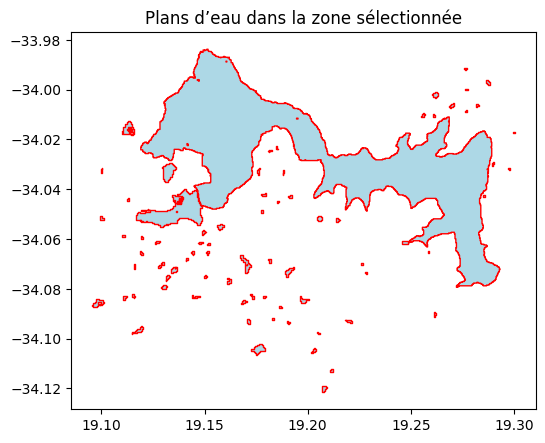

In [4]:
## 3.3.3b Charger et visualiser les polygones des plans d’eau
#Ensuite, utilisez la fonction get_waterbodies pour charger un GeoDataFrame contenant les polygones des plans d’eau ainsi que leurs attributs pour la zone d’intérêt (AOI). Puis, tracez-les afin de vérifier visuellement le contour principal du barrage.
#_________________________________________________________

# Récupérer les polygones et attributs des plans d’eau dans toute la zone

waterbodies_gdf = get_waterbodies(bbox, crs="EPSG:4326")

 

# Afficher les polygones des plans d’eau sur un graphique 2D simple

waterbodies_gdf.plot(figsize=(6, 6), column=None, legend=False, edgecolor="red", facecolor="lightblue")

plt.title("Plans d’eau dans la zone sélectionnée");

#_________________________________________________________

#Ce que vous allez faire: 

#Les géométries de tous les polygones (pour tous les plans d’eau de la zone) doivent être téléchargées dans un GeoDataFrame, puis affichées. Le plus grand polygone devrait correspondre au contour de l'étendue historique du barrage de Theewaterskloof. Les polygones plus petits représentent des plans d’eau secondaires.

#Interprétation du polygone: l​e polygone du barrage délimite toutes les zones où l’eau a été détectée à hauteur d'au moins 5 % du temps au cours de la période historique. Pour Theewaterskloof, cela correspond assez fidèlement à l’étendue maximale du réservoir. Les zones à l’intérieur de ce polygone ont donc été recouvertes d’eau à un moment ou à un autre. Sur les bords, cela peut inclure des zones inondables qui sont généralement sèches, mais qui sont parfois submergées. S’il y a plusieurs polygones présents, notez leurs tailles : le plus grand correspond au barrage principal. Les plus petits peuvent correspondre à des réservoirs secondaires ou même à de larges segments de rivière. Cette étape permet de confirmer que nous avons bien identifié le plan d’eau du barrage dans le jeu de données.

#Figure 3.3.2: Polygones des plans d’eau dans la zone du barrage de Theewaterskloof

In [5]:
#_________________________________________________________
print(waterbodies_gdf.columns)
#_________________________________________________________
#Figure 3.3.3: Attributs du jeu de données des plans d’eau

Index(['id', 'wb_id', 'area_m2', 'length_m', 'uid', 'perim_m', 'last_obs_date',
       'last_valid_obs_date', 'last_valid_obs', 'last_attrs_update_date',
       'geometry'],
      dtype='object')


            area_wet_m2  percent_wet  area_dry_m2  percent_dry  \
date                                                             
1984-06-09       8100.0       100.00          0.0         0.00   
1984-07-04       7200.0        88.89        900.0        11.11   
1984-10-15       4500.0        55.56       3600.0        44.44   
1984-11-25       4500.0        55.56       3600.0        44.44   
1985-04-09       3600.0        44.44       4500.0        55.56   

            area_invalid_m2  percent_invalid  area_observed_m2  \
date                                                             
1984-06-09              0.0              0.0            8100.0   
1984-07-04              0.0              0.0            8100.0   
1984-10-15              0.0              0.0            8100.0   
1984-11-25              0.0              0.0            8100.0   
1985-04-09              0.0              0.0            8100.0   

            percent_observed  percent_wet_rolling_median  
date           

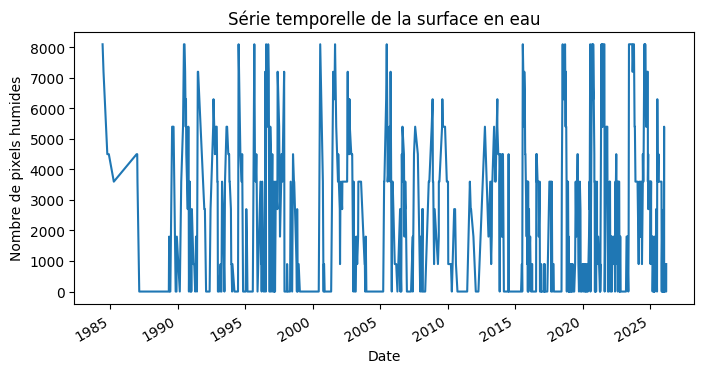

In [7]:
## 3.3.3c  Série temporelle de la surface en eau
# maintenant le polygone principal du barrage (par exemple, le premier ou celui ayant la plus grande superficie), puis récupérez sa série temporelle de surface en eau à l’aide de la fonction get_time_series. Cela renvoie un xarray ou un DataFrame Pandas indiquant le nombre de pixels couverts par l'eau à chaque date d'observation.
#_________________________________________________________

# Sélectionner le plan d’eau principal (ici, on prend le premier ; ajuster si nécessaire)

dam_waterbody = waterbodies_gdf.iloc[0]

 

# Récupérer la série temporelle de la surface en eau pour ce plan d’eau

ts = get_time_series(waterbody=dam_waterbody)

 

# Afficher les premières lignes de la série temporelle

print(ts.head())

 

#Tracer la série temporelle du nombre de pixels humides au fil du temps

ts["area_wet_m2"].plot(figsize=(8,4))

plt.title("Série temporelle de la surface en eau")

plt.xlabel("Date")

plt.ylabel("Nombre de pixels humides");

#_________________________________________________________ 

#Ce que vous allez faire: 

#Vous allez extraire l’évolution de la surface en eau du barrage (en m²) au fil du temps. Le graphique obtenu mettra en évidence les variations saisonnières, les périodes de sécheresse marquée (forte diminution de la surface en eau), ainsi que les pics de crue (augmentation soudaine de la surface). Dans le cas du barrage de Theewaterskloof, vous devriez observer un creux important autour de 2017–2018 (période dite du Day Zero), suivi d’un redressement progressif.

#Figure 3.3.4: Wet Surface Area Time Series for Theewaterskloof Dam

In [8]:
## 3.3.4 Vectorisation des plans d’eau à partir de WOfS
#Pour reproduire (ou personnaliser) le service des plans d’eau, nous allons vectoriser manuellement à partir du produit WOfS All-Time Summary. Ce produit indique, pour chaque pixel, sa fréquence (c’est-à-dire la fraction de temps où il a été recouvert d’eau depuis 1984). En appliquant un seuil de fréquence ≥ 5 %, on identifie les pixels correspondant à des plans d’eau, que l’on convertit ensuite en polygones vectoriels.

  

#3.3.4a Charger les donnees de WOfS All-Time Summary
# Open Data Cube pour charger le produit wofs_ls_summary_alltime pour notre zone d’intérêt (AOI). Ce jeu de données contient une seule image temporelle représentant la fréquence de présence d’eau.
#_________________________________________________________

import datacube

 

# Initialiser l’instance de DataCube

dc = datacube.Datacube(app="waterbody_vectorisation")

 

# Charger WOfS All-Time Summary pour la zone d’intérêt

ds = dc.load(product="wofs_ls_summary_alltime",

             x=(xlim[0], xlim[1]),

             y=(ylim[1], ylim[0]),  # note: DataCube attend (min_lat, max_lat) dans l’axe Y

             output_crs="EPSG:4326",  # Utiliser un système de coordonnées lat/lon pour plus de simplicité

             resolution=(0.00025, -0.00025),  # Résolution d’environ 30 m (en degrés)

             measurements=["frequency"])


print(ds)
#_________________________________________________________
#Ce que vous faites ici: 

#La couche de fréquence de l’eau pour le rectangle délimitant (bounding box) est récupérée. ds.frequency  est un tableau 2D indiquant, pour chaque pixel, la fraction d’observations claires où de l’eau a été détectée. Les valeurs prises par ce tableau varient de 0 à 1.
#Figure 3.3.5: Informations sur la carte de fréquence d’eau WOfS

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 1, latitude: 560, longitude: 800)
Coordinates:
  * time         (time) datetime64[ns] 8B 2004-12-31T11:59:59.999999
  * latitude     (latitude) float64 4kB -34.12 -34.12 -34.12 ... -33.98 -33.98
  * longitude    (longitude) float64 6kB 19.3 19.3 19.3 19.3 ... 19.1 19.1 19.1
    spatial_ref  int32 4B 4326
Data variables:
    frequency    (time, latitude, longitude) float32 2MB 0.001129 ... nan
Attributes:
    crs:           EPSG:4326
    grid_mapping:  spatial_ref


Nombre total de pixels dans le masque: 448000
Pixels identifiés comme plan d’eau (True): 81959


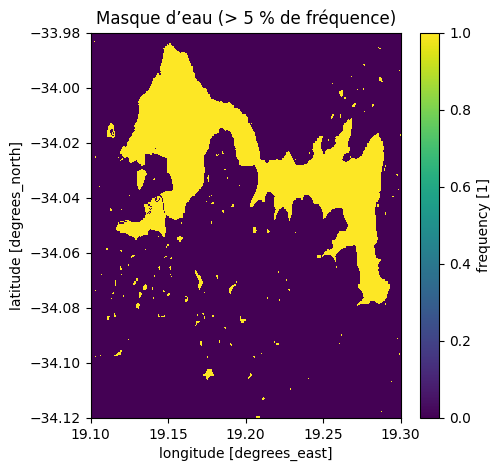

In [9]:
## 3.3.4.b Appliquer un seuil sur la fréquence d’eau pour identifier les plans d’eau 
#Appliquez un seuil aux données de frequency pour isoler les pixels ayant été recouverts d’eau au moins 5 % du temps (c’est-à-dire l’empreinte historique des plans d’eau). Ensuite, affichez le masque booléen obtenu.
#_________________________________________________________

# Sélectionner les données de fréquence (il peut y avoir une dimension temporelle de taille 1, donc utiliser .isel pour obtenir le tableau 2D)

freq = ds.frequency.isel(time=0)  # all-time summary ne doit contenir qu’une seule étape temporelle 

water_mask = freq > 0.05  # boolean DataArray: True pour les pixels ayant été de l’eau dans ≥ 5 % des observations

 

print("Nombre total de pixels dans le masque:", water_mask.count().item())

print("Pixels identifiés comme plan d’eau (True):", int(water_mask.sum().item()))

 

# Affichage rapide du masque

water_mask.plot(figsize=(5,5))

plt.title("Masque d’eau (> 5 % de fréquence)");

#_________________________________________________________

#Ce que vous faites ici:  

#Conversion de la fréquence en masque binaire : tous les pixels dont la fréquence d’eau est supérieure à 5 % sont marqués comme True. Ce procédé reproduit le critère utilisé par le service pour définir un « plan d’eau historique ».
#Figure 3.3.6: Masque des plans d’eau historiques (fréquence d’eau > 5 %)

In [10]:
## 3.3.4c Vectoriser le masque
#Passons maintenant à la vectorisation : nous allons convertir ce masque raster en polygones vectoriels. La fonction xr_vectorize du module deafrica_tools.spatial, fournie par les outils de Digital Earth Africa, permet de le faire facilement. En arrière-plan, cette fonction utilise rasterio pour tracer les contours des zones contiguës marquées True.
#_________________________________________________________

from deafrica_tools.spatial import xr_vectorize

 

# Vectoriser le masque d’eau pour obtenir un GeoDataFrame de polygones

water_gdf = xr_vectorize(water_mask,

                         crs=ds.crs,

                         mask=water_mask.values == 1,    # Ne conserver que les valeurs True (zones identifiées comme plans d’eau)

                         output_path="waterbodies.shp")  # Exporter directement au format Shapefile

 

# Afficher les premiers attributs des polygonesprint(water_gdf.head())

#_________________________________________________________

#Ce que vous faites ici:  

#Les zones contiguës marquées True sont converties en polygones vectoriels, puis exportées au format waterbodies.shp. Le GeoDataFrame résultant (water_gdf) contient une ligne par polygone. Pour notre zone, le fichier waterbodies.shp devrait contenir plusieurs polygones : on s’attend à trouver un grand polygone correspondant au barrage de Theewaterskloof, ainsi que quelques petits polygones représentant d’autres zones d’eau dans le périmètre analysé.
#Figure 3.3.7: Informations sur les polygones vectorisés des plans d’eau à partir du masque historique

Exporting vector data to waterbodies.shp


In [ ]:
## 3.3.4d Inspecter et visualiser les polygones vectorisés
#Charger le fichier Shapefile et l’afficher afin de confirmer le contour du barrage.
#________________________________________________________

import geopandas as gpd

 

# Lire le fichier Shapefile exporté

waterbodies_shp = gpd.read_file("waterbodies.shp")

print("Le Shapefile contient {} entités.".format(len(waterbodies_shp)))

 

# Afficher les géométries du Shapefile

waterbodies_shp.plot(figsize=(6,6), color="lightblue", edgecolor="black")

plt.title("Plans d’eau vectorisés  (>5% water frequency)");

#_________________________________________________________

#Ce que vous faites ici: 

#Vérification de l’alignement des polygones du fichier Shapefile avec les limites attendues du barrage. Vous devriez observer un polygone correspondant à l’empreinte du barrage de Theewaterskloof.

#Figure 3.3.8: Polygones vectorisés des plans d’eau à partir du seuillage manuel (fréquence > 5 %)

In [11]:
#Nous avons généré manuellement les contours des plans d’eau à partir des données brutes ! Nous avons en quelque sorte reproduit le fonctionnement du service Waterbodies en appliquant un seuil sur WOfS pour identifier les pixels d’eau, puis les vectoriser. L’avantage de cette méthode manuelle est que vous pouvez ajuster le seuil selon vos besoins ou vous concentrer sur des périodes spécifiques (par exemple, un résumé annuel pour ne voir que les zones actuellement en eau) L’inconvénient est qu'il faut écrire plus de code et bien comprendre les données, ce que le service fait automatiquement. Les deux approches sont utiles, tout dépend du contexte et des objectifs de votre analyse.

## 3.3.4e Sélectionner le polygone principal du barrage
#Si plusieurs polygones sont présents (par exemple, de petits étangs à proximité du barrage), sélectionnez le plus grand en superficie. Commencez par reprojeter les données dans un système de coordonnées à surface équivalente afin de garantir une mesure de surface précise.
#_________________________________________________________

# S'assurer que le GeoDataFrame du Shapefile utilise une projection adaptée au calcul de surface

if waterbodies_shp.crs.is_geographic:

    waterbodies_shp = waterbodies_shp.to_crs("EPSG:6933")  # Utiliser une projection à surface équivalente (ex. : Africa Albers) pour le calcul des superficies

 

# Ajouter une colonne "area_m2" (surface en mètres carrés) pour chaque polygone 

waterbodies_shp["area_m2"] = waterbodies_shp.geometry.area

 

# Sélectionner le polygone ayant la surface maximale

main_polygon = waterbodies_shp.iloc[ waterbodies_shp["area_m2"].idxmax() ]

print("Surface du polygone principal sélectionné (m²):", main_polygon["area_m2"])

#_________________________________________________________

#Ce que vous faites ici: 

#Conversion vers une projection à surface équivalente (EPSG : 6933), puis calcul de la surface de chaque polygone. Le polygone correspondant au réservoir du barrage devrait avoir la plus grande surface de tous les polygones. Nous l'identifierons pour une utilisation ultérieure.

#À présent, main_polygon représente la géométrie du barrage. Si vous utilisiez les données du service waterbodies_gdf, vous auriez pu identifier le polygone du barrage de manière similaire (par exemple, en sélectionnant la plus grande surface ou en utilisant un geohash connu). Dans ce cas, vous disposeriez déjà d'un geohash ou d'un index correspondant au barrage.

NameError: name 'waterbodies_shp' is not defined